In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_filtered_features_3lakh.csv')
df.head()

,text,Label,filtered_text_eng,tokenized_text,Preprocessed_Text,filtered_tokenized_words
0,"I'm done with it all. Any tips?First of all, i...",2,done with it Any of if going to comment get or...,"['done', 'go', 'comment', 'get', 'plea', 'unde...",done go comment get plea understand want hear ...,"['kill', 'pain', 'sorri', 'hate']"
1,i 20m was a problem child when grow up i frequ...,1,i was a problem child when grow up i frequent ...,"['problem', 'child', 'grow', 'frequent', 'got'...",problem child grow frequent got troubl junior ...,"['ill', 'awkward', 'steal', 'silenc', 'wrong',..."
2,I officially hate my school We have to start p...,0,I officially hate my school We have to start o...,"['offici', 'hate', 'school', 'start', 'enter',...",offici hate school start enter caus fix,"['offici', 'hate', 'school', 'start', 'enter',..."
3,but onc again depress love to take that from m...,1,but onc again depress love to take that from m...,"['onc', 'depress', 'love', 'take', 'angri', 'w...",onc depress love take angri want cri wont come...,"['cri', 'angri', 'damn', 'tire', 'depress']"
4,"Starting today, I'm going to attempt to fix my...",0,Starting going to attempt to fix my sleep sche...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc...",start go attempt fix sleep schedul school coup...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc..."


In [3]:
df1 = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_all_features.csv')
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,2781,2782,2783,2784,2785,2786,2787,2788,2789,2790
0,-0.311691,0.207526,0.294796,-0.370256,-0.463946,0.004523,0.103642,0.023245,-0.273210,-0.043930,...,1.174970,-0.131030,0.581713,1.317829,0.545300,-4.912285,2.002302,-2.429308,2.313626,0.068317
1,-0.314458,0.200302,0.248307,-0.337924,-0.354438,-0.029178,0.120759,0.028209,-0.381361,-0.010982,...,-0.170022,-1.057125,0.506787,0.481089,-0.443753,-1.015673,0.295432,-1.521313,-0.511028,-0.270724
2,-0.258834,0.199409,0.255281,-0.329083,-0.421285,-0.008494,0.122459,0.000529,-0.345936,-0.007731,...,-0.475023,-2.049421,-2.095686,-2.270150,2.747774,-4.004583,-1.818186,-3.040991,-0.021306,1.718746
3,-0.348873,0.164237,0.313819,-0.395596,-0.340182,-0.008542,0.077583,-0.002947,-0.369009,0.005620,...,1.116820,0.496508,2.048395,-0.856290,0.582634,-1.573221,0.650254,-1.483610,0.080408,-0.893238
4,-0.258569,0.201524,0.242732,-0.321395,-0.432100,-0.044947,0.111697,0.009705,-0.350573,-0.033735,...,-0.861691,-1.552952,-0.070507,-2.612564,0.754670,-5.594344,3.663493,-0.440785,1.437596,-0.616004


In [4]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)

In [5]:
# Apply PCA
pca = PCA(n_components=100, random_state=42)
X = pca.fit_transform(X_scaled)

In [6]:
y = df['Label'].values

In [18]:
# Define the path to the directory where you want to save the plots
save_directory = "E:/Works/10. Mental Health Disorder/Plots/RNN-LSTM"

# Ensure the directory exists
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

In [8]:
# Split the data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, shuffle=True)

In [9]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Count:", torch.cuda.device_count())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

CUDA Available: True
GPU Count: 1
GPU Name: NVIDIA GeForce RTX 4070 Laptop GPU


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import time

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

num_features = X_train.shape[1] 

class HybridRNNLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers):
        super(HybridRNNLSTM, self).__init__()
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True)
        self.lstm = nn.LSTM(input_size=hidden_dim, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        lstm_out, _ = self.lstm(rnn_out)
        out = lstm_out[:, -1, :]
        out = self.fc(out)
        return out

# Reshape data to (batch, time_step=1, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Convert to tensors and move to device
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model, loss, optimizer, scheduler
input_dim = num_features
hidden_dim = 32
output_dim = len(np.unique(y_train))
n_layers = 2

model = HybridRNNLSTM(input_dim, hidden_dim, output_dim, n_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

# Training loop
epochs = 50
patience = 10
best_val_loss = float('inf')
early_stop_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()  # Start timing

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train_predictions = 0
    total_train_samples = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train_predictions += (predicted == batch_y).sum().item()
        total_train_samples += batch_y.size(0)

    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_train_accuracy = correct_train_predictions / total_train_samples
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    # Validation
    model.eval()
    epoch_val_loss = 0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val_predictions += (predicted == batch_y).sum().item()
            total_val_samples += batch_y.size(0)

    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_val_accuracy = correct_val_predictions / total_val_samples
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_accuracy:.4f}")

    scheduler.step(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

end_time = time.time()

Using device: cuda


E:\Works\10. Mental Health Disorder\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 0.2609, Train Acc: 0.8821, Val Loss: 0.2122, Val Acc: 0.9116
Epoch 2/50, Train Loss: 0.2123, Train Acc: 0.9115, Val Loss: 0.2124, Val Acc: 0.9096
Epoch 3/50, Train Loss: 0.2091, Train Acc: 0.9129, Val Loss: 0.2147, Val Acc: 0.9100
Epoch 4/50, Train Loss: 0.2079, Train Acc: 0.9132, Val Loss: 0.2140, Val Acc: 0.9112
Epoch 5/50, Train Loss: 0.2069, Train Acc: 0.9132, Val Loss: 0.2061, Val Acc: 0.9130
Epoch 6/50, Train Loss: 0.2067, Train Acc: 0.9140, Val Loss: 0.2080, Val Acc: 0.9131
Epoch 7/50, Train Loss: 0.2060, Train Acc: 0.9139, Val Loss: 0.2068, Val Acc: 0.9146
Epoch 8/50, Train Loss: 0.2058, Train Acc: 0.9134, Val Loss: 0.2082, Val Acc: 0.9132
Epoch 9/50, Train Loss: 0.2055, Train Acc: 0.9142, Val Loss: 0.2055, Val Acc: 0.9139
Epoch 10/50, Train Loss: 0.2052, Train Acc: 0.9148, Val Loss: 0.2060, Val Acc: 0.9150
Epoch 11/50, Train Loss: 0.2049, Train Acc: 0.9141, Val Loss: 0.2053, Val Acc: 0.9133
Epoch 12/50, Train Loss: 0.2054, Train Acc: 0.9137, Val Loss: 0

In [11]:
training_time_minutes = (end_time - start_time) / 60
print(f"\nTraining completed in {training_time_minutes:.2f} minutes")


Training completed in 28.72 minutes


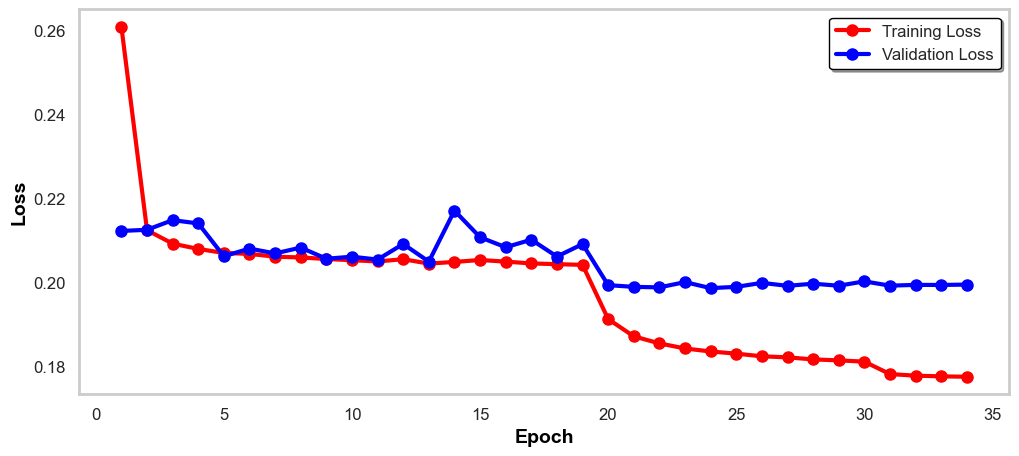

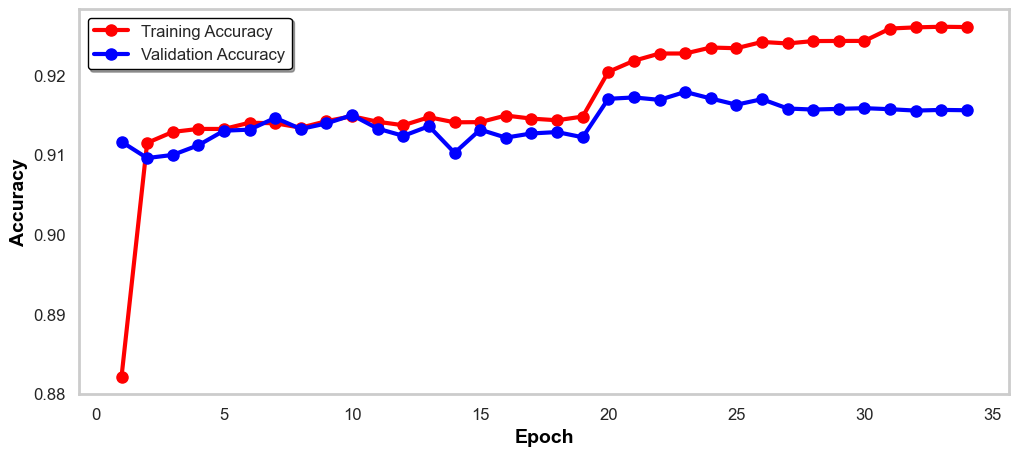

In [19]:
# Plot training and validation losses
plt.figure(figsize=(12, 5))

# Use bright colors for the lines
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Training Loss', color='red', lw=3, markersize=8) 
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss', color='blue', lw=3, markersize=8) 

# Increase font size and make labels bold for clarity
plt.xlabel('Epoch', fontsize=14, weight='bold', color='black')
plt.ylabel('Loss', fontsize=14, weight='bold', color='black')

# Customize legend for better readability
plt.legend(fontsize=12, loc='best', frameon=True, fancybox=True, edgecolor='black', shadow=True)

# Make the axes thicker for better visibility
plt.gca().spines['top'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)
plt.gca().spines['left'].set_linewidth(2)

# Customize tick parameters for larger ticks
plt.tick_params(axis='both', which='major', labelsize=12, length=6, width=2)

# Disable the grid
plt.grid(False)

# Save the plot with high DPI for better resolution
plt.savefig(os.path.join(save_directory, "loss_curve_rnn_lstm_enhanced_colors.png"), dpi=300, bbox_inches='tight')
plt.show()




# Plot training and validation accuracies
plt.figure(figsize=(12, 5))

# Use bright colors for the lines
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, marker='o', label='Training Accuracy', color='red', lw=3, markersize=8) 
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy', color='blue', lw=3, markersize=8) 

# Increase font size and make labels bold for clarity
plt.xlabel('Epoch', fontsize=14, weight='bold', color='black')
plt.ylabel('Accuracy', fontsize=14, weight='bold', color='black')

# Customize legend for better readability
plt.legend(fontsize=12, loc='best', frameon=True, fancybox=True, edgecolor='black', shadow=True)

# Make the axes thicker for better visibility
plt.gca().spines['top'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)
plt.gca().spines['left'].set_linewidth(2)

# Customize tick parameters for larger ticks
plt.tick_params(axis='both', which='major', labelsize=12, length=6, width=2)

# Disable the grid
plt.grid(False)

# Save the plot with high DPI for better resolution
plt.savefig(os.path.join(save_directory, "accuracy_curve_rnn_lstm_enhanced_colors.png"), dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Evaluation for RNN-LSTM model
model.eval()  # Ensure the RNN-LSTM model is in evaluation mode
all_preds_rnn_lstm = []
all_labels_rnn_lstm = []
all_probs_rnn_lstm = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:  # Assuming test_loader is defined and loaded with test data
        outputs = model(batch_x)  # Forward pass through the RNN-LSTM model
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds_rnn_lstm.extend(preds.cpu().tolist())
        all_labels_rnn_lstm.extend(batch_y.cpu().tolist())
        all_probs_rnn_lstm.extend(probs.cpu().tolist())

# Convert lists to PyTorch tensors
all_preds_rnn_lstm = torch.tensor(all_preds_rnn_lstm)
all_labels_rnn_lstm = torch.tensor(all_labels_rnn_lstm)
all_probs_rnn_lstm = torch.tensor(all_probs_rnn_lstm)

# Calculate metrics
accuracy_rnn_lstm = (all_preds_rnn_lstm == all_labels_rnn_lstm).float().mean().item()

# Convert tensors to lists
y_true_rnn_lstm = all_labels_rnn_lstm.tolist()
y_pred_rnn_lstm = all_preds_rnn_lstm.tolist()

# Classification Report with 8 decimal places
print("Classification Report (RNN-LSTM):\n", classification_report(y_true_rnn_lstm, y_pred_rnn_lstm, digits=8))

# Calculate Accuracy
accuracy_rnn_lstm = accuracy_score(y_true_rnn_lstm, y_pred_rnn_lstm)
print(f"Accuracy (RNN-LSTM): {accuracy_rnn_lstm * 100:.6f}%")

# Calculate Precision (for multi-class, average='weighted')
precision_rnn_lstm = precision_score(y_true_rnn_lstm, y_pred_rnn_lstm, average='weighted')
print(f"Precision (RNN-LSTM): {precision_rnn_lstm * 100:.6f}%")

# Calculate Recall (for multi-class, average='weighted')
recall_rnn_lstm = recall_score(y_true_rnn_lstm, y_pred_rnn_lstm, average='weighted')
print(f"Recall (RNN-LSTM): {recall_rnn_lstm * 100:.6f}%")

# Calculate F1 Score (for multi-class, average='weighted')
f1_rnn_lstm = f1_score(y_true_rnn_lstm, y_pred_rnn_lstm, average='weighted')
print(f"F1 Score (RNN-LSTM): {f1_rnn_lstm * 100:.6f}%")

Classification Report (RNN-LSTM):
               precision    recall  f1-score   support

           0  0.99726983 0.99878475 0.99802672     19749
           1  0.88007073 0.87348371 0.87676485     19373
           2  0.86704921 0.87248066 0.86975646     18358

    accuracy                      0.91621434     57480
   macro avg  0.91479659 0.91491638 0.91484934     57480
weighted avg  0.91617922 0.91621434 0.91618970     57480

Accuracy (RNN-LSTM): 91.621434%
Precision (RNN-LSTM): 91.617922%
Recall (RNN-LSTM): 91.621434%
F1 Score (RNN-LSTM): 91.618970%


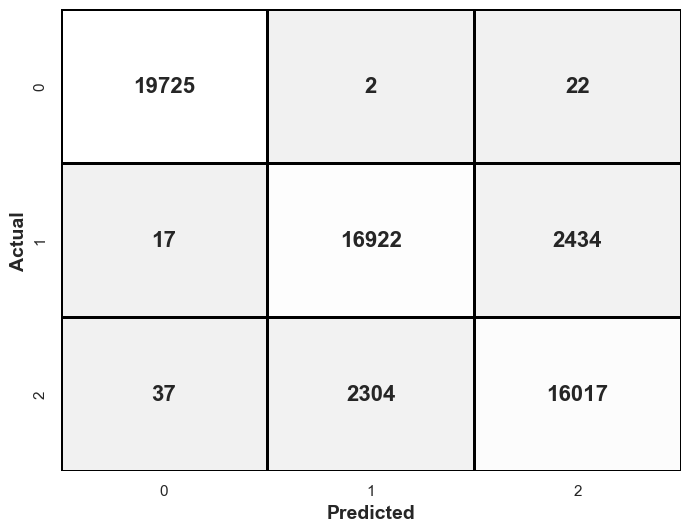

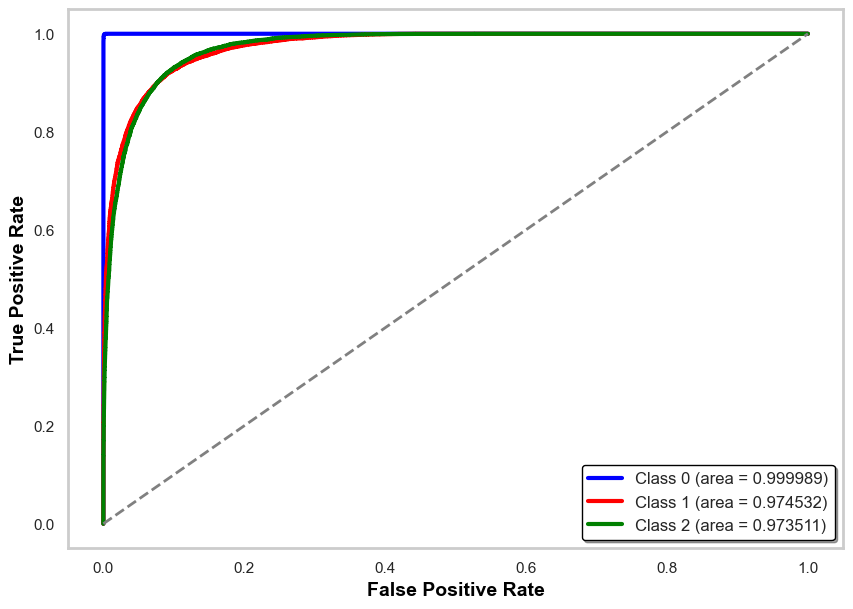

AUC for Class 0: 0.999989
AUC for Class 1: 0.974532
AUC for Class 2: 0.973511
Overall AUC Score (Weighted Average): 0.982677


In [21]:
# Function to plot confusion matrix
def plot_confusion_matrix(model_name, conf_matrix, save_path):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    sns.set(style="whitegrid")  # Seaborn style for cleaner plots

    plt.figure(figsize=(8, 6))

    # Custom colormap for white background
    cmap = sns.light_palette("white", as_cmap=True)

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=cmap, 
                annot_kws={"size": 16, "weight": "bold"}, linewidths=2, linecolor='black', cbar=False)

    plt.xlabel('Predicted', fontsize=14, weight='bold')
    plt.ylabel('Actual', fontsize=14, weight='bold')

    # Thicker axis borders for sharpness
    plt.gca().spines['top'].set_linewidth(2)
    plt.gca().spines['right'].set_linewidth(2)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)

    # Save plot with high DPI
    plt.savefig(os.path.join(save_path, f"{model_name}_confusion_matrix_enhanced.png"), bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

# Function to plot ROC curve and calculate AUC
def plot_roc_curve(model_name, y_test, y_prob, save_path):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Binarize the labels for multi-class ROC AUC
    y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])  # Assuming 3 classes, adjust if more/less classes
    n_classes = y_test_binarized.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = ['blue', 'red', 'green']  # Adjust colors if more classes
    total_auc = 0

    # Convert y_prob from list of lists to a 2D list (list of lists)
    y_prob = [[float(prob) for prob in probs] for probs in y_prob]

    # Calculate ROC metrics and plot
    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        # Convert lists to tensors and then to numpy arrays for roc_curve
        y_test_bin = [row[i] for row in y_test_binarized]
        y_prob_class = [row[i] for row in y_prob]
        fpr[i], tpr[i], _ = roc_curve(y_test_bin, y_prob_class)
        roc_auc[i] = auc(fpr[i], tpr[i])
        total_auc += roc_auc[i]
        
        # Plot ROC curve for each class
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=3,  # Increased line width for clarity
                 label='Class {0} (area = {1:0.6f})'.format(i, roc_auc[i]))

    avg_auc = total_auc / n_classes
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

    plt.xlabel('False Positive Rate', fontsize=14, weight='bold', color='black')
    plt.ylabel('True Positive Rate', fontsize=14, weight='bold', color='black')

    # Enhance the legend with larger text, shadow, and bold font
    plt.legend(loc='lower right', fontsize=12, frameon=True, fancybox=True, edgecolor='black', shadow=True)

    # Thicker borders for a sharper look
    plt.gca().spines['top'].set_linewidth(2)
    plt.gca().spines['right'].set_linewidth(2)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)

    # Disable the grid
    plt.grid(False)

    # Save plot with higher DPI
    plt.savefig(os.path.join(save_path, f"{model_name}_roc_curve_enhanced.png"), bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

    # Print AUC for each class and the overall AUC score
    for i in range(n_classes):
        print(f"AUC for Class {i}: {roc_auc[i]:.6f}")
    
    print(f"Overall AUC Score (Weighted Average): {avg_auc:.6f}")

    return avg_auc

# Compute confusion matrix for RNN-LSTM
conf_matrix_rnn_lstm = confusion_matrix(y_true_rnn_lstm, y_pred_rnn_lstm)

# Plot and save the confusion matrix for RNN-LSTM
plot_confusion_matrix("RNN_LSTM", conf_matrix_rnn_lstm, save_directory)

# Convert probabilities to list of lists for RNN-LSTM
y_prob_rnn_lstm = [prob for prob in all_probs_rnn_lstm]

# Plot ROC AUC and calculate for RNN-LSTM
roc_auc_rnn_lstm = plot_roc_curve("RNN_LSTM", y_true_rnn_lstm, y_prob_rnn_lstm, save_directory)